## Chapter 2 
- Build and train a very simple neural network with backpropagation

### From this:
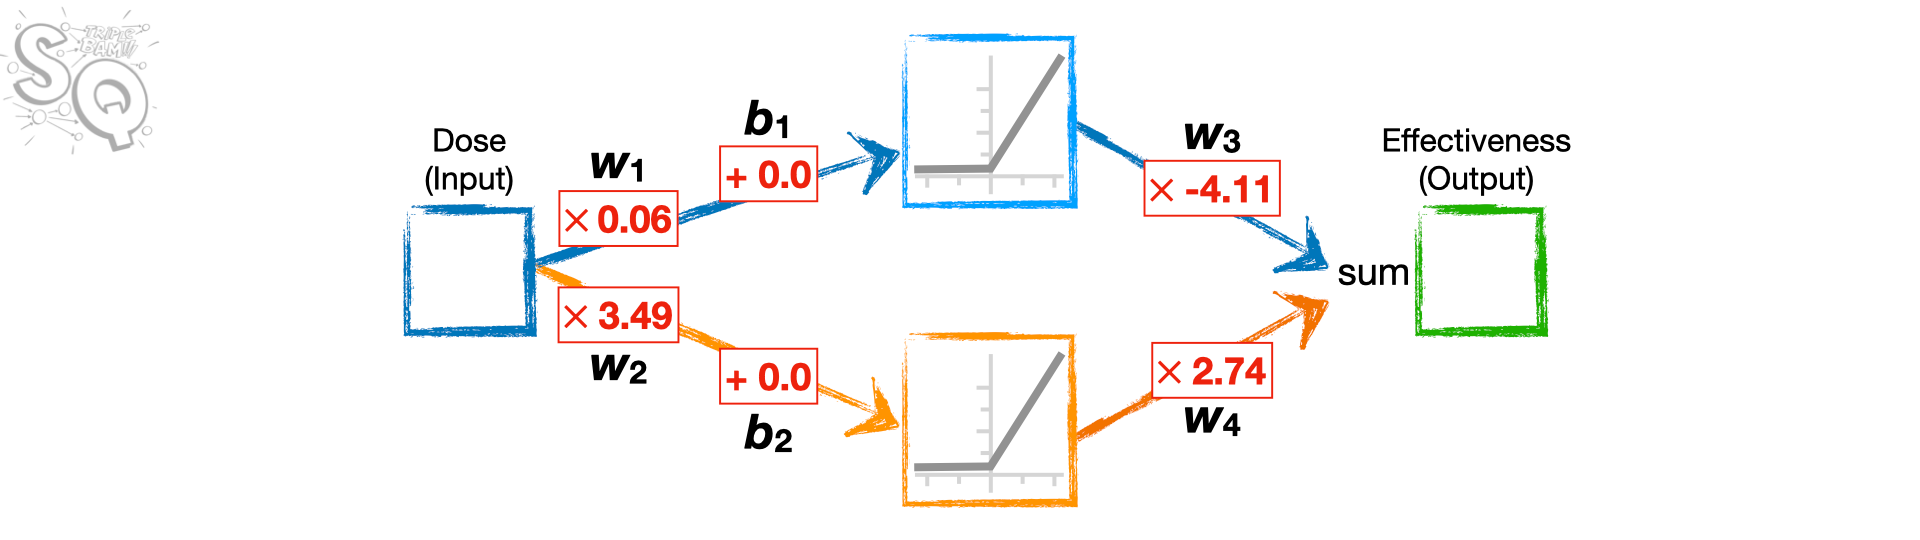
### To this:
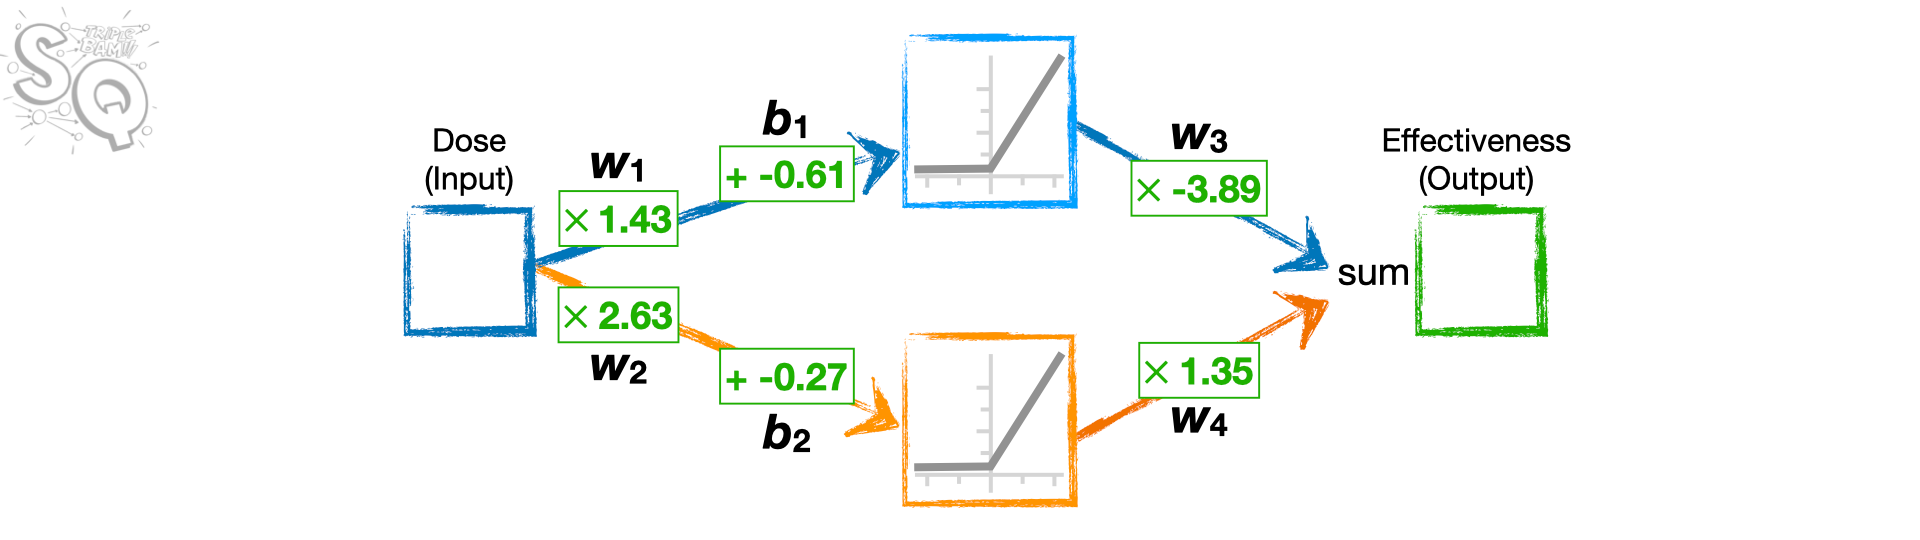

In [2]:
import torch 
import torch.nn as nn 
import torch.nn.functional as F # This gives us relu()
from torch.optim import SGD # SGD is short of Stochastic Gradient Descent, but
                            # the way we'll use it, passing in all of the training
                            # data at once instead of passing it random subsets,
                            # it will act just like plain old Gradient Descent.

import lightning as L 
from torch.utils.data import TensorDataset, DataLoader 
import matplotlib.pyplot as plt 
import seaborn as sns 

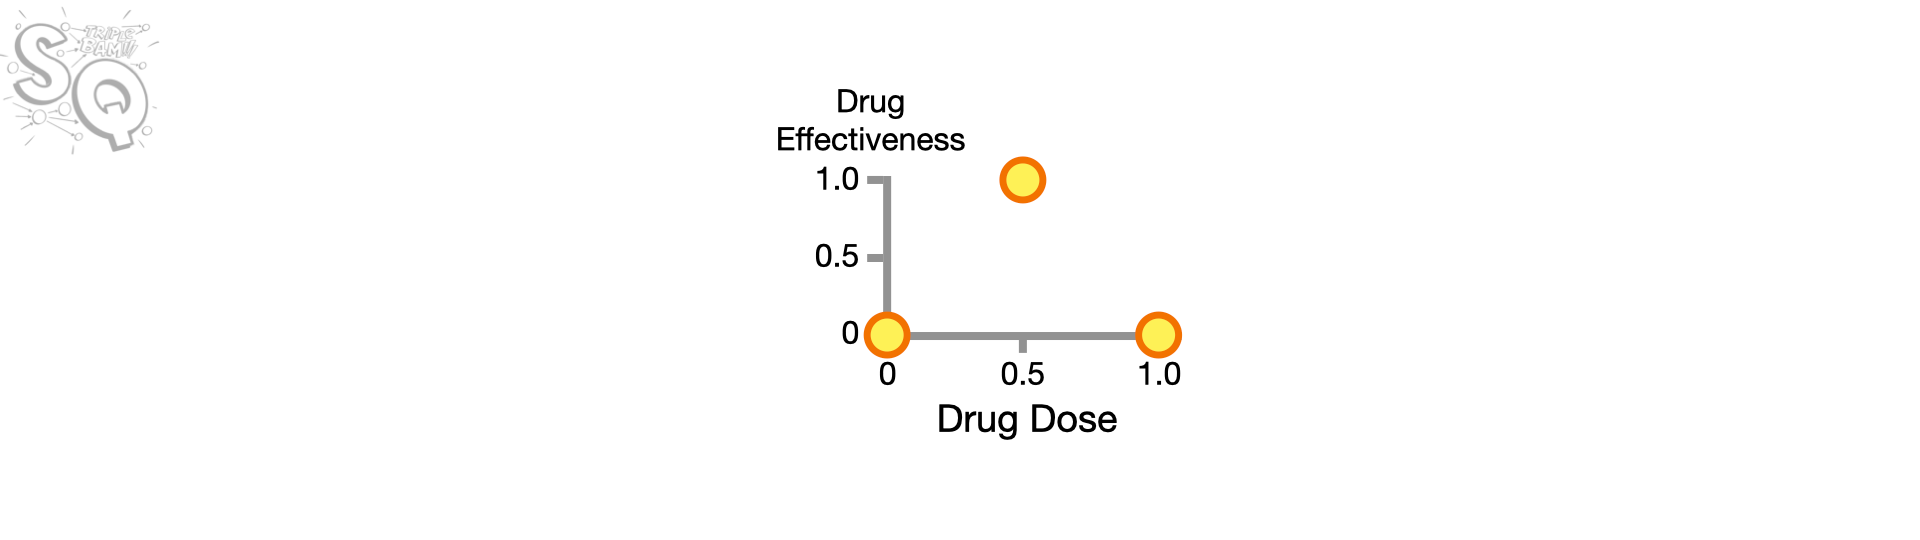

In [22]:
training_inputs = torch.tensor([0.0, 0.5, 1.0])
training_labels = torch.tensor([0.0, 1.0, 0.0])

training_dataset = TensorDataset(training_inputs, training_labels)
print(training_dataset.tensors)
dataloader = DataLoader(training_dataset, batch_size=1)

(tensor([0.0000, 0.5000, 1.0000]), tensor([0., 1., 0.]))


In [23]:
class myNN(L.LightningModule):
    def __init__(self):
        super().__init__()
        self.w1 = nn.Parameter(torch.tensor(0.06))
        self.b1 = nn.Parameter(torch.tensor(0.0))

        self.w2 = nn.Parameter(torch.tensor(3.49))
        self.b2 = nn.Parameter(torch.tensor(0.0))

        self.w3 = nn.Parameter(torch.tensor(-4.11))
        self.w4 = nn.Parameter(torch.tensor(2.74))

        self.loss = nn.MSELoss(reduction='sum')
    
    def forward(self, input_values):
        top_x_axis_values = (input_values * self.w1) + self.b1
        bottom_x_axis_values = (input_values * self.w2) + self.b2

        top_y_axis_values = F.relu(top_x_axis_values)
        bottom_y_axis_values = F.relu(bottom_x_axis_values)

        output_values = (top_y_axis_values * self.w3) + (bottom_y_axis_values * self.w4)

        return output_values
    
    def training_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self.forward(inputs)
        loss = self.loss(outputs, labels)
        return loss
    
    def configure_optimizers(self):
        return SGD(self.parameters(), lr=0.01)

In [24]:
model = myNN()

for name, param in model.named_parameters():
    print(name, torch.round(param.data, decimals=2))

w1 tensor(0.0600)
b1 tensor(0.)
w2 tensor(3.4900)
b2 tensor(0.)
w3 tensor(-4.1100)
w4 tensor(2.7400)


In [25]:
output_values = model(training_inputs)
torch.round(output_values, decimals=2)

tensor([0.0000, 4.6600, 9.3200], grad_fn=<RoundBackward1>)

In [26]:
input_doses = torch.linspace(start=0, end=1, steps=11)
input_doses

tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
        0.9000, 1.0000])

In [27]:
output_values = model(input_doses)
output_values

tensor([0.0000, 0.9316, 1.8632, 2.7948, 3.7264, 4.6580, 5.5896, 6.5212, 7.4528,
        8.3844, 9.3160], grad_fn=<AddBackward0>)

Text(0.5, 0, 'Dose')

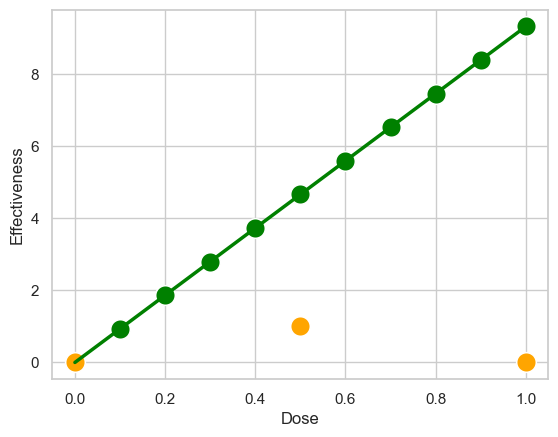

In [28]:
sns.set(style="whitegrid")

## First, draw the individual output points
sns.scatterplot(x=input_doses.detach().numpy(),
                y=output_values.detach().numpy(),
                color='green',
                s=200)

## Now connect those points with a line
sns.lineplot(x=input_doses.detach().numpy(),
             y=output_values.detach().numpy(),
             color='green',
             linewidth=2.5)

## Add the values in the training dataset
sns.scatterplot(x=training_inputs.detach().numpy(),
                y=training_labels.detach().numpy(),
                color='orange',
                s=200)

## Now label the y- and x-axes.
plt.ylabel('Effectiveness')
plt.xlabel('Dose')

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 5070') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MSELoss │      0 │ train │     0 │
│   │ other params │ n/a     │      6 │ n/a   │   n/a │
└───┴──────────────┴─────────┴────────┴───────┴───────┘

Trainable params: 6                                                                                                
Non-trainable params: 0                                                                                            
Total params: 6                                                                                                    
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 1                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\Theo\source\repos\.venvs\neural_networks_cuda\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\Theo\source\repos\.venvs\neural_networks_cuda\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=500` reached.


w1 tensor(1.4790)
b1 tensor(-0.5680)
w2 tensor(2.6980)
b2 tensor(-0.2580)
w3 tensor(-4.2400)
w4 tensor(1.5840)


Text(0.5, 0, 'Dose')

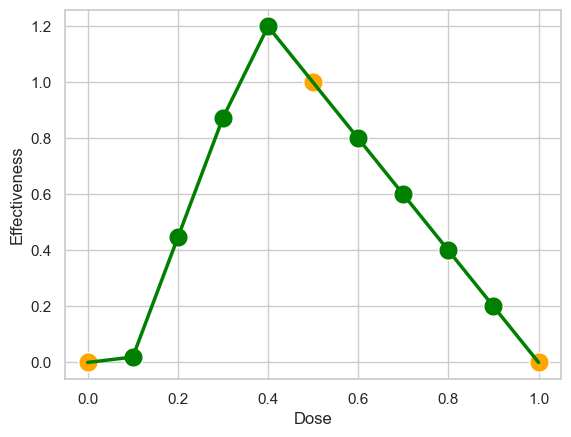

In [ ]:
model = myNN()
trainer = L.Trainer(max_epochs=500,
                    logger=False,
                    enable_checkpointing=False,
                    enable_progress_bar=False)

trainer.fit(model, train_dataloaders=dataloader)

for name, param in model.named_parameters():
    print(name, torch.round(param.data, decimals=3))

output_values = model(input_doses)
torch.round(output_values, decimals=2)

sns.set(style="whitegrid")

sns.scatterplot(x=input_doses,
                y=output_values.detach().numpy(),
                color='green',
                s=200)

sns.lineplot(x=input_doses,
             y=output_values.detach().numpy(), ## NOTE: We call .detatch() because...
             color='green',
             linewidth=2.5)

sns.scatterplot(x=training_inputs,
                y=training_labels,
                color='orange',
                s=200)

plt.ylabel('Effectiveness')
plt.xlabel('Dose')

